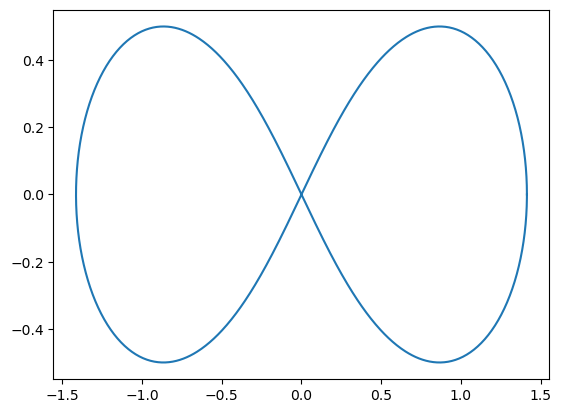

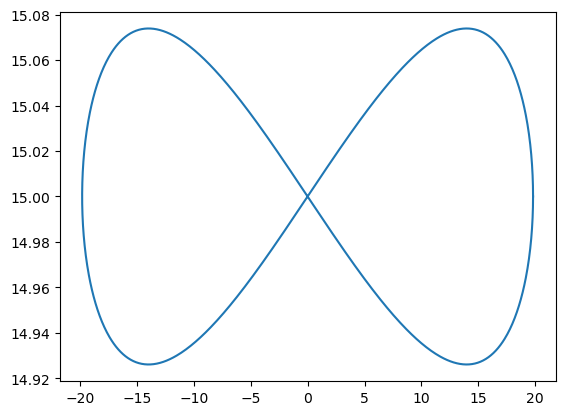

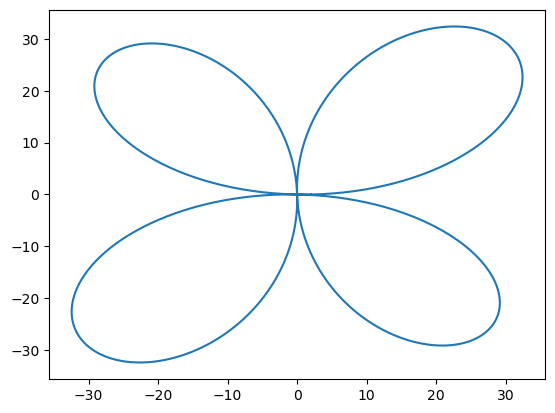

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import math

alpha=1

t = np.linspace(0, 2*np.pi, num=1000) # 10^3 points 

x = [alpha * np.sqrt(2)*np.cos(i) / (np.sin(i)**2+1) for i in t]

y = [alpha * np.sqrt(2)*np.cos(i)*np.sin(i) / (np.sin(i)**2+1) for i in t]

plt.figure(1)
plt.plot(x, y)

def lemniscata_3_focos(w, a=2000, b=15, c=10):
    # Coordenadas de los focos (puedes ajustarlos según lo desees)
    f1_x, f1_y = -a, 0  # Foco 1
    f2_x, f2_y =  a, 0  # Foco 2
    f3_x, f3_y =  0, b  # Foco 3 

    fx = (f1_x + f2_x) / 2 + (a * np.cos(w)) / (1 + np.sin(w)**2 + c**2)
    fy = (f3_y) + (b * np.sin(w) * np.cos(w)) / (1 + np.sin(w)**2 + c**2)

    return np.array([fx, fy])

[f_x,f_y]=lemniscata_3_focos(t)

plt.figure(2)
plt.plot(f_x,f_y)

def flor_6_petalos(w, radius=2, modulation=20):
    """
    Genera coordenadas para una flor de 6 pétalos.
    :param w: Parámetro angular (array o escalar).
    :param radius: Radio máximo de la flor.
    :param modulation: Factor que define la forma de los pétalos.
    :return: Coordenadas (x, y) de la trayectoria.
    """
    # Fórmula paramétrica para una flor de 6 pétalos
    r = radius * (1 + modulation * np.sin(2 * w))  # Modulación para generar los pétalos
    x = r * np.cos(w)  # Coordenada x
    y = r * np.sin(w)  # Coordenada y

    return np.array([x, y])

[f_x,f_y]=flor_6_petalos(t)

plt.figure(3)
plt.plot(f_x,f_y)

In [15]:
A=np.zeros([1,3])
B=np.ones([1,3])
print(A-B)
print(A.T-B.T)
np.linalg.norm(A.T-B.T)

[[-1. -1. -1.]]
[[-1.]
 [-1.]
 [-1.]]


1.7320508075688772

In [17]:
import cvxpy as cp

cp.norm(A.T-B.T)

Expression(CONSTANT, NONNEGATIVE, ())

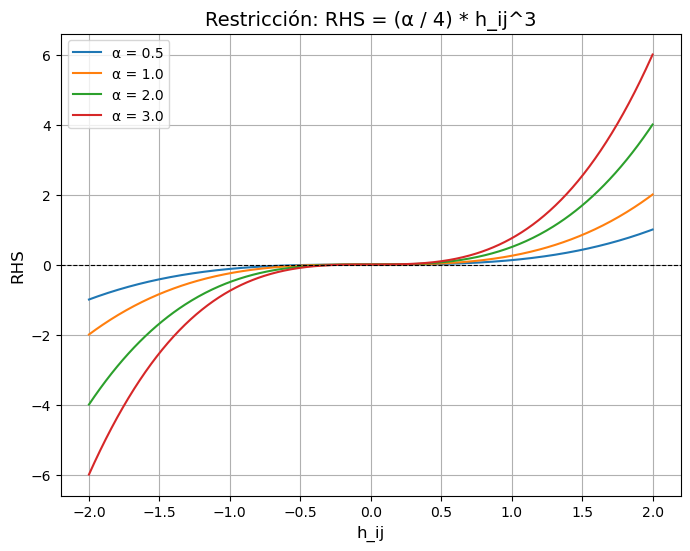

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# Rango de valores de h_ij
h_ij = np.linspace(-2, 2, 500)  # Distancias relativas, pueden ser negativas o positivas

# Valores de alpha
alpha_values = [0.5, 1.0, 2.0, 3.0]  # Diferentes valores de alpha para comparar

# Graficar las curvas
plt.figure(figsize=(8, 6))
for alpha in alpha_values:
    rhs = (alpha / 4) * h_ij**3  # Restricción RHS para cada alpha
    plt.plot(h_ij, rhs, label=f'α = {alpha}')

# Configurar el gráfico
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)  # Línea horizontal en y=0
plt.title("Restricción: RHS = (α / 4) * h_ij^3", fontsize=14)
plt.xlabel("h_ij", fontsize=12)
plt.ylabel("RHS", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)
plt.show()


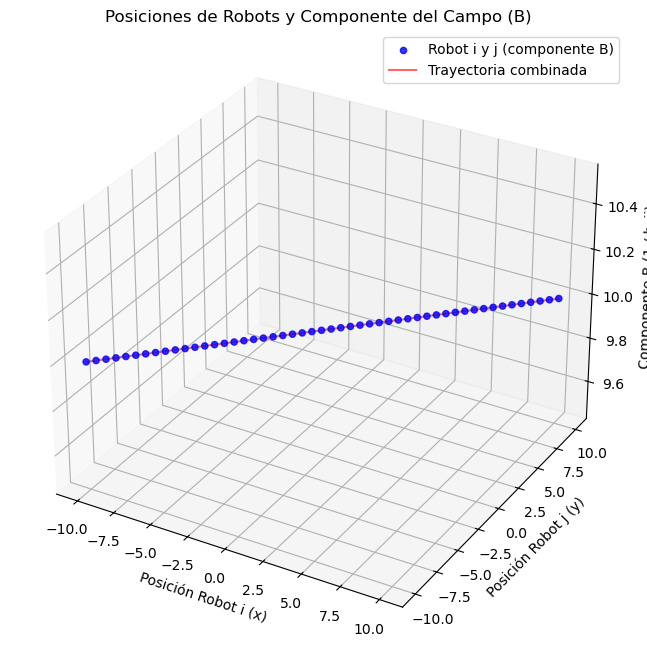

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_3d_field(xi, xj, yi, yj, h_ij):
    """
    Plotea en 3D las posiciones de los robots (i, j) y el componente B inverso de h_ij.

    :param xi: Posiciones en x del robot i.
    :param xj: Posiciones en x del robot j.
    :param yi: Posiciones en y del robot i.
    :param yj: Posiciones en y del robot j.
    :param h_ij: Distancia entre los robots i y j.
    """
    # Calcular B como inverso de h_ij
    B = 1 / h_ij

    # Crear el gráfico 3D
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Trazar los datos
    ax.scatter(xi, xj, B, c='b', label='Robot i y j (componente B)', alpha=0.8, marker='o')
    ax.plot(xi, xj, B, color='r', alpha=0.6, label='Trayectoria combinada')

    # Configuración de los ejes
    ax.set_xlabel('Posición Robot i (x)')
    ax.set_ylabel('Posición Robot j (y)')
    ax.set_zlabel('Componente B (1 / h_ij)')
    ax.set_title('Posiciones de Robots y Componente del Campo (B)')
    ax.legend()

    # Mostrar el gráfico
    plt.show()

# Ejemplo de datos
xi = np.linspace(-10, 10, 50)  # Posiciones x del robot i
xj = np.linspace(-10, 10, 50)  # Posiciones x del robot j
yi = np.linspace(-10, 10, 50)  # Posiciones y del robot i
yj = np.linspace(-10, 10, 50)  # Posiciones y del robot j
h_ij = np.abs(xi - xj) + 0.1  # Simulación de h_ij (evitar divisiones por 0)

# Llamar a la función de ploteo
plot_3d_field(xi, xj, yi, yj, h_ij)


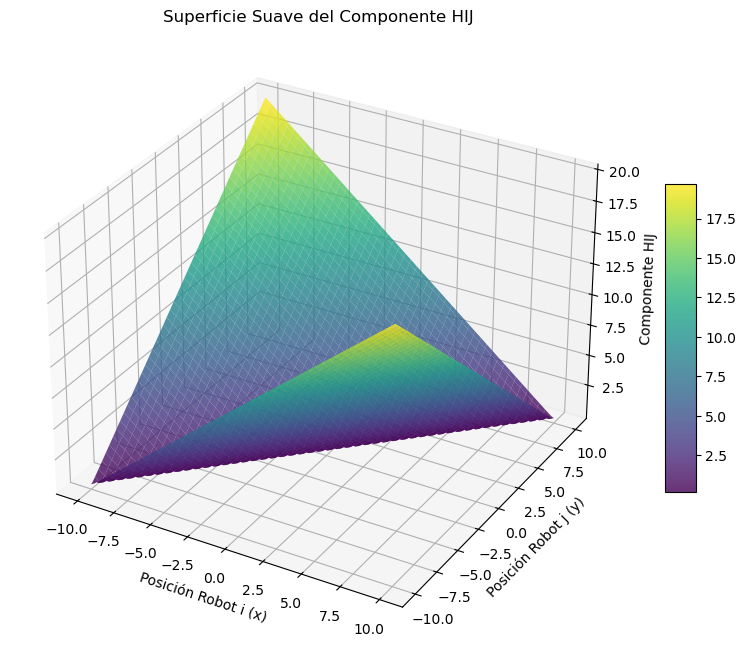

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_3d_surface(x_min, x_max, y_min, y_max, num_points):
    """
    Genera un gráfico 3D suave basado en las posiciones de los robots y el componente B inverso de h_ij.
    :param x_min: Mínimo valor para el espacio de x.
    :param x_max: Máximo valor para el espacio de x.
    :param y_min: Mínimo valor para el espacio de y.
    :param y_max: Máximo valor para el espacio de y.
    :param num_points: Número de puntos en cada eje para la cuadrícula.
    """
    # Generar una cuadrícula de puntos (xi, xj)
    xi = np.linspace(x_min, x_max, num_points)
    xj = np.linspace(y_min, y_max, num_points)
    XI, XJ = np.meshgrid(xi, xj)  # Crear una malla 2D para posiciones de los robots

    # Calcular h_ij (distancia relativa) y B (componente inverso)
    HIJ = np.sqrt((XI - XJ)**2 + 0.1**2)  # Distancia h_ij con corrección para evitar divisiones por 0
    #B = 1 / HIJ  # Componente B inverso de h_ij

    # Crear el gráfico 3D
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Graficar la superficie
    surf = ax.plot_surface(XI, XJ, HIJ, cmap='viridis', edgecolor='none', alpha=0.8)

    # Configuración del gráfico
    ax.set_xlabel('Posición Robot i (x)')
    ax.set_ylabel('Posición Robot j (y)')
    ax.set_zlabel('Componente HIJ ')
    ax.set_title('Superficie Suave del Componente HIJ')
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)  # Barra de color para indicar valores de B

    # Mostrar el gráfico
    plt.show()

# Parámetros de ejemplo
x_min, x_max = -10, 10  # Rango para las posiciones de x
y_min, y_max = -10, 10  # Rango para las posiciones de y
num_points = 100  # Resolución de la cuadrícula

# Llamar a la función para generar el gráfico
plot_3d_surface(x_min, x_max, y_min, y_max, num_points)


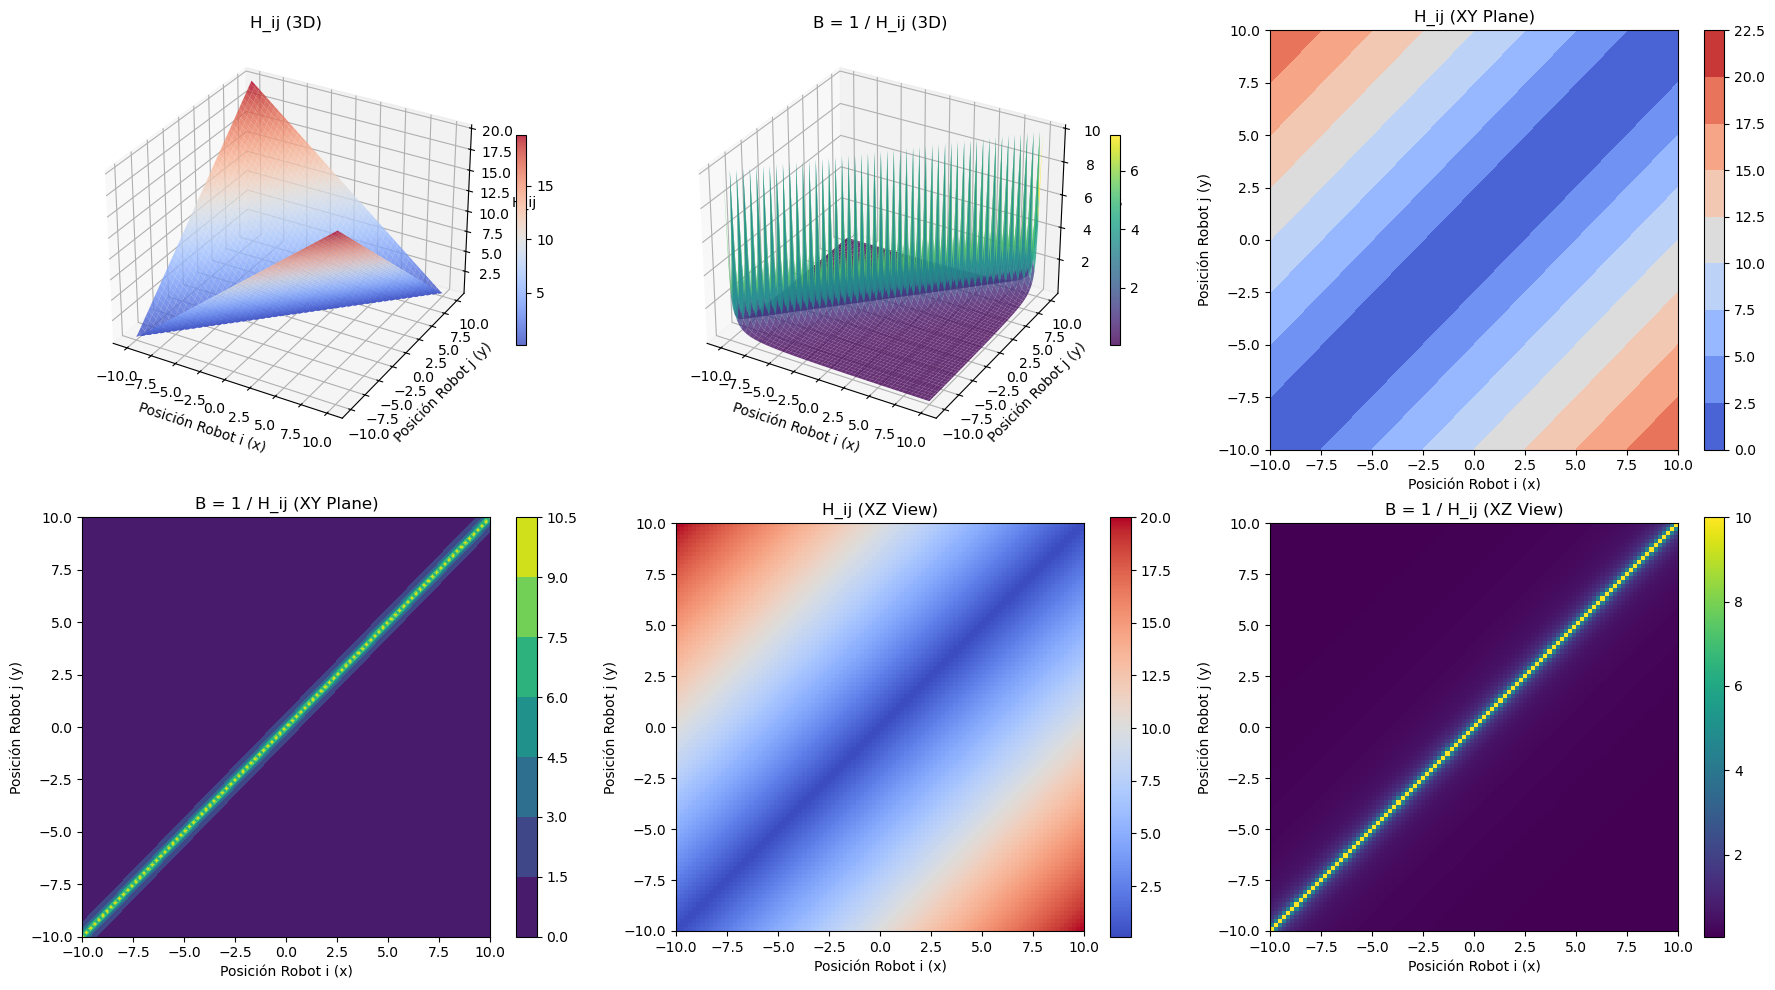

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_hij_and_b(x_min, x_max, y_min, y_max, num_points):
    """
    Genera gráficos de H_ij y B en diferentes mapas de colores, incluyendo vistas 3D y 2D.
    :param x_min: Mínimo valor para el espacio de x.
    :param x_max: Máximo valor para el espacio de x.
    :param y_min: Mínimo valor para el espacio de y.
    :param y_max: Máximo valor para el espacio de y.
    :param num_points: Número de puntos en cada eje para la cuadrícula.
    """
    # Generar una cuadrícula de puntos (xi, xj)
    xi = np.linspace(x_min, x_max, num_points)
    xj = np.linspace(y_min, y_max, num_points)
    XI, XJ = np.meshgrid(xi, xj)  # Crear una malla 2D para posiciones de los robots

    # Calcular H_ij (distancia relativa) y B (componente inverso)
    HIJ = np.sqrt((XI - XJ)**2 + 0.1**2)  # Distancia h_ij con corrección para evitar divisiones por 0
    B = 1 / HIJ  # Componente B inverso de h_ij

    # Crear figura con subgráficos
    fig = plt.figure(figsize=(18, 10))

    # Vista 3D de H_ij
    ax1 = fig.add_subplot(231, projection='3d')
    surf_hij = ax1.plot_surface(XI, XJ, HIJ, cmap='coolwarm', edgecolor='none', alpha=0.8)
    ax1.set_title("H_ij (3D)")
    ax1.set_xlabel("Posición Robot i (x)")
    ax1.set_ylabel("Posición Robot j (y)")
    ax1.set_zlabel("H_ij")
    fig.colorbar(surf_hij, ax=ax1, shrink=0.5)

    # Vista 3D de B
    ax2 = fig.add_subplot(232, projection='3d')
    surf_b = ax2.plot_surface(XI, XJ, B, cmap='viridis', edgecolor='none', alpha=0.8)
    ax2.set_title("B = 1 / H_ij (3D)")
    ax2.set_xlabel("Posición Robot i (x)")
    ax2.set_ylabel("Posición Robot j (y)")
    ax2.set_zlabel("B")
    fig.colorbar(surf_b, ax=ax2, shrink=0.5)

    # Vista 2D xy para H_ij
    ax3 = fig.add_subplot(233)
    c_hij = ax3.contourf(XI, XJ, HIJ, cmap='coolwarm')
    ax3.set_title("H_ij (XY Plane)")
    ax3.set_xlabel("Posición Robot i (x)")
    ax3.set_ylabel("Posición Robot j (y)")
    fig.colorbar(c_hij, ax=ax3)

    # Vista 2D xy para B
    ax4 = fig.add_subplot(234)
    c_b = ax4.contourf(XI, XJ, B, cmap='viridis')
    ax4.set_title("B = 1 / H_ij (XY Plane)")
    ax4.set_xlabel("Posición Robot i (x)")
    ax4.set_ylabel("Posición Robot j (y)")
    fig.colorbar(c_b, ax=ax4)

    # Vista 2D xz para H_ij
    ax5 = fig.add_subplot(235)
    im_hij = ax5.imshow(HIJ, cmap='coolwarm', origin='lower', extent=[x_min, x_max, y_min, y_max])
    ax5.set_title("H_ij (XZ View)")
    ax5.set_xlabel("Posición Robot i (x)")
    ax5.set_ylabel("Posición Robot j (y)")
    fig.colorbar(im_hij, ax=ax5)

    # Vista 2D xz para B
    ax6 = fig.add_subplot(236)
    im_b = ax6.imshow(B, cmap='viridis', origin='lower', extent=[x_min, x_max, y_min, y_max])
    ax6.set_title("B = 1 / H_ij (XZ View)")
    ax6.set_xlabel("Posición Robot i (x)")
    ax6.set_ylabel("Posición Robot j (y)")
    fig.colorbar(im_b, ax=ax6)

    # Ajustar diseño y mostrar
    plt.tight_layout()
    plt.show()

# Parámetros de ejemplo
x_min, x_max = -10, 10  # Rango para las posiciones de x
y_min, y_max = -10, 10  # Rango para las posiciones de y
num_points = 100  # Resolución de la cuadrícula

# Llamar a la función para generar los gráficos
plot_hij_and_b(x_min, x_max, y_min, y_max, num_points)


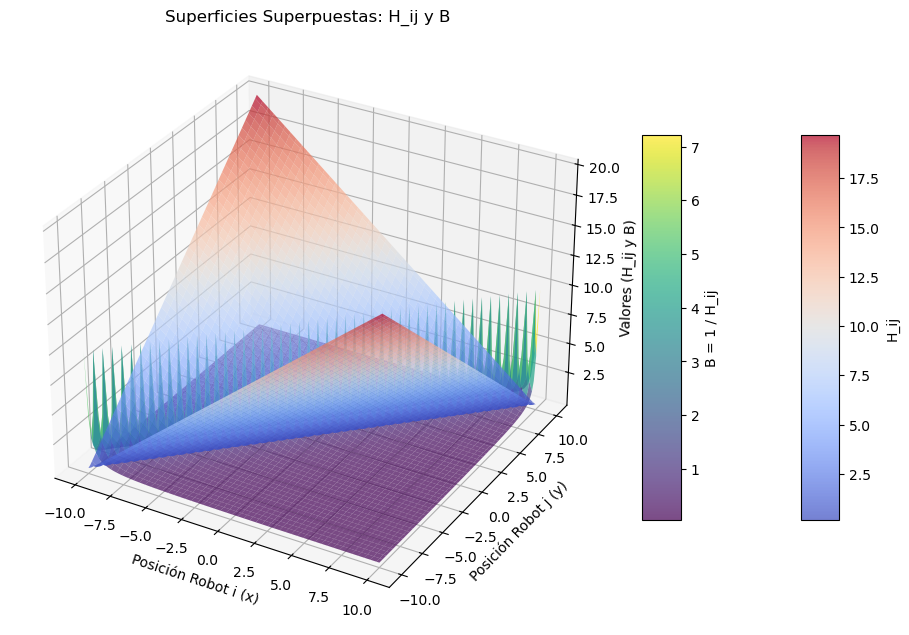

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_superposed_3d(x_min, x_max, y_min, y_max, num_points):
    """
    Genera un gráfico 3D con superficies superpuestas para H_ij y B.
    :param x_min: Mínimo valor para el espacio de x.
    :param x_max: Máximo valor para el espacio de x.
    :param y_min: Mínimo valor para el espacio de y.
    :param y_max: Máximo valor para el espacio de y.
    :param num_points: Número de puntos en cada eje para la cuadrícula.
    """
    # Generar una cuadrícula de puntos (xi, xj)
    xi = np.linspace(x_min, x_max, num_points)
    xj = np.linspace(y_min, y_max, num_points)
    XI, XJ = np.meshgrid(xi, xj)  # Crear una malla 2D para posiciones de los robots

    # Calcular H_ij (distancia relativa) y B (componente inverso)
    HIJ = np.sqrt((XI - XJ)**2 + 0.1**2)  # Distancia h_ij con corrección para evitar divisiones por 0
    B = 1 / HIJ  # Componente B inverso de h_ij

    # Crear el gráfico 3D
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Graficar la superficie de H_ij
    surf_hij = ax.plot_surface(XI, XJ, HIJ, cmap='coolwarm', edgecolor='none', alpha=0.7, label='H_ij')
    # Graficar la superficie de B
    surf_b = ax.plot_surface(XI, XJ, B, cmap='viridis', edgecolor='none', alpha=0.7, label='B = 1 / H_ij')

    # Configuración del gráfico
    ax.set_xlabel('Posición Robot i (x)')
    ax.set_ylabel('Posición Robot j (y)')
    ax.set_zlabel('Valores (H_ij y B)')
    ax.set_title('Superficies Superpuestas: H_ij y B')

    # Agregar barras de color para cada superficie
    fig.colorbar(surf_hij, ax=ax, shrink=0.5, aspect=10, label='H_ij')
    fig.colorbar(surf_b, ax=ax, shrink=0.5, aspect=10, label='B = 1 / H_ij')

    # Mostrar el gráfico
    plt.show()

# Parámetros de ejemplo
x_min, x_max = -10, 10  # Rango para las posiciones de x
y_min, y_max = -10, 10  # Rango para las posiciones de y
num_points = 100  # Resolución de la cuadrícula

# Llamar a la función para generar el gráfico
plot_superposed_3d(x_min, x_max, y_min, y_max, num_points)


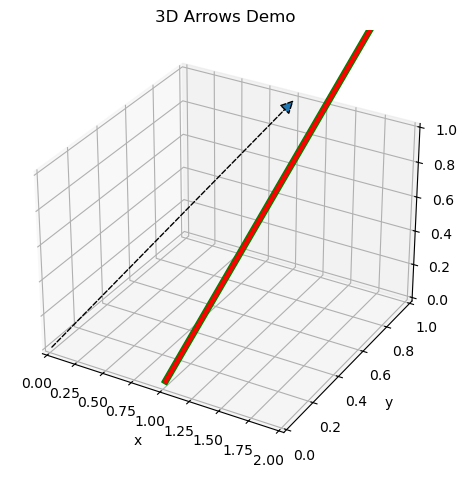

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d.proj3d import proj_transform
from mpl_toolkits.mplot3d.axes3d import Axes3D

class Arrow3D(FancyArrowPatch):

    def __init__(self, x, y, z, dx, dy, dz, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._xyz = (x, y, z)
        self._dxdydz = (dx, dy, dz)

    def draw(self, renderer):
        x1, y1, z1 = self._xyz
        dx, dy, dz = self._dxdydz
        x2, y2, z2 = (x1 + dx, y1 + dy, z1 + dz)

        xs, ys, zs = proj_transform((x1, x2), (y1, y2), (z1, z2), self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        super().draw(renderer)
        
    def do_3d_projection(self, renderer=None):
        x1, y1, z1 = self._xyz
        dx, dy, dz = self._dxdydz
        x2, y2, z2 = (x1 + dx, y1 + dy, z1 + dz)

        xs, ys, zs = proj_transform((x1, x2), (y1, y2), (z1, z2), self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))

        return np.min(zs) 

def _arrow3D(ax, x, y, z, dx, dy, dz, *args, **kwargs):
    '''Add an 3d arrow to an `Axes3D` instance.'''

    arrow = Arrow3D(x, y, z, dx, dy, dz, *args, **kwargs)
    ax.add_artist(arrow)


setattr(Axes3D, 'arrow3D', _arrow3D)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.set_xlim(0,2)
ax.arrow3D(0,0,0,
           1,1,1,
           mutation_scale=20,
           arrowstyle="-|>",
           linestyle='dashed')
ax.arrow3D(1,0,0,
           1,1,2,
           mutation_scale=20,
           ec ='green',
           fc='red')
ax.set_title('3D Arrows Demo')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
fig.tight_layout()

In [25]:
T=np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9],
    [10, 11, 12]
])

print(T[1,:])
len(T[1,:])

[4 5 6]


3

In [2]:
import numpy as np
colors = [np.random.rand(3).tolist() for _ in range(3)]

print(1./colors)

TypeError: unsupported operand type(s) for /: 'float' and 'list'

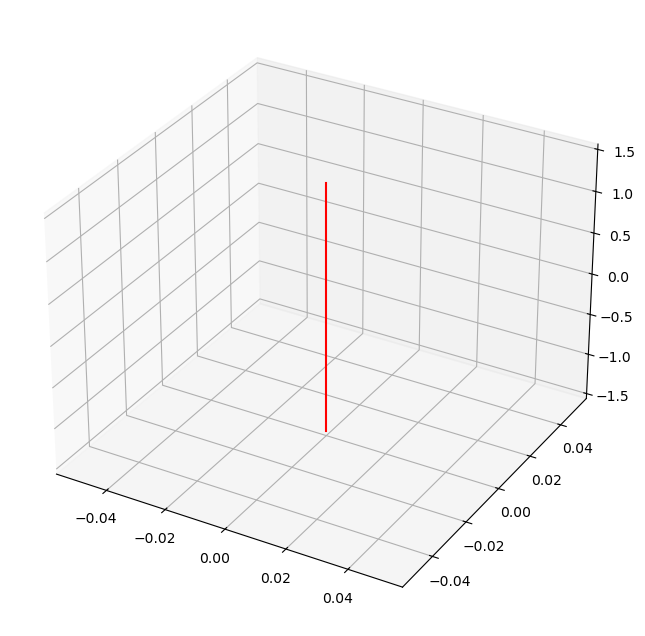

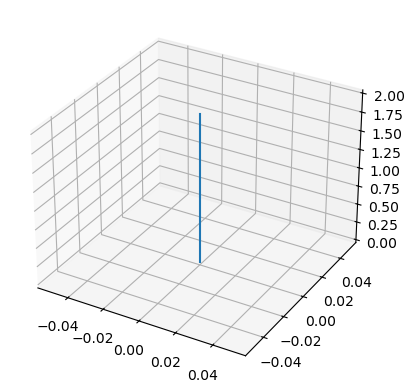

In [27]:
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import Axes3D
x=[0,0,0,0]
y=[0,0,0,0]

t1=x[-1]
t2=y[-1]

Z=np.linspace(-1.5, 1.5, 10)
X=np.ones_like(Z)*0
Y=np.ones_like(Z)*0


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot3D(X,Y,Z, color='red')

fig2=plt.figure()
ax=fig2.add_subplot(111, projection='3d')
ax.plot([0,0],[0,0],[0,2])

1.428571428571427


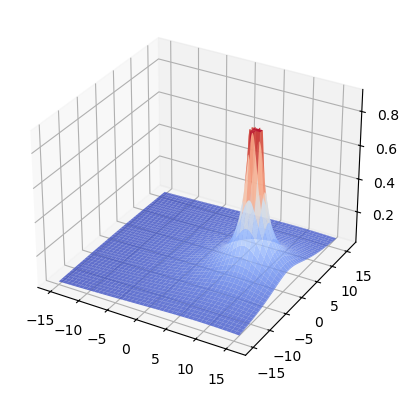

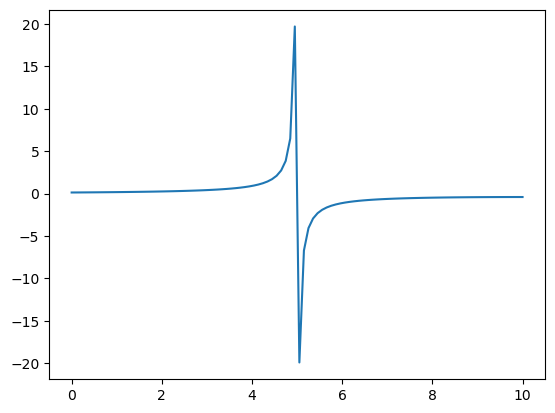

In [153]:
R=5

def distancias_puntos(xp,yp,x,y):
    d=np.zeros_like(xp)
    for i in range(len(xp[1,:])):
        for j in range(len(xp[:,1])):
            d[j,i]=np.sqrt((xp[j,i]-x)**2 + (yp[j,i]-y)**2)
            if d[j,i]<1:
                d[j,i]=1
            d[j,i]=1/d[j,i]

    return d

def distancias_puntos_h(xp,yp,x,y):
     return ((np.sqrt((xp-x)**2 + (yp-y)**2))**2 - R**2)/(2*R)


def P_matrix(n):
    A=np.eye(n+1)
    A[n,n]=0
    return (A)

def h_func(xi,xj,R,n):
    dist=np.linalg.norm(P_matrix(n) @ (xi-xj))
    return dist**2 - R**2

puntos = np.arange(-15,16,0.1)  

[X,Y] = np.meshgrid(puntos,puntos)

D=np.zeros_like(X)

D=distancias_puntos(X,Y,10,0)

D=D*1/((distancias_puntos_h(4,0,10,0)))

print(1/((distancias_puntos_h(6,6,10,10))))

fig=plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(X, Y, D, cmap='coolwarm', edgecolor='none', alpha=0.8)

xx=np.linspace(0,10,100)
yy=1/distancias_puntos_h(xx,0,10,0)
plt.figure()
plt.plot(xx,yy)